In [62]:
import torch
import torch.nn as nn

torch.manual_seed(0)

net = nn.Sequential(
    nn.Linear(1, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
)

X_train = torch.rand([5, 1])
N = X_train.shape[0]

def get_grad_vec(x: torch.Tensor):
    net.zero_grad()
    out = net(x.unsqueeze(0))
    out.backward()
    grad_vec = torch.cat([p.grad.flatten() for p in net.parameters()], dim=0)
    return grad_vec



grad_vectors = torch.stack([get_grad_vec(x) for x in X_train])

K = grad_vectors @ grad_vectors.T

torch.allclose(K, K.T)
eigenvalues = torch.linalg.eigvalsh(K)
eigenvalues > 0

tensor([True, True, True, True, True])

In [43]:
for param in net.parameters():
    print(param.grad.flatten())
    grad_vec = torch.cat([p.grad.flatten() for p in net.parameters()])

grad_vec.shape

tensor([ 0.0766,  0.0869, -0.0783, -0.0603,  0.0228,  0.1260, -0.0338,  0.1176])
tensor([ 0.1386,  0.1572, -0.1417, -0.1091,  0.0413,  0.2279, -0.0611,  0.2127])
tensor([-0.0926,  0.5089, -0.6395, -0.5395, -0.8237, -0.4731, -0.3996,  0.4426])
tensor([1.])


torch.Size([25])

In [72]:
import numpy as np

A = np.array([[4, 2],
              [1, 3]]) 

eigval, eigvec = np.linalg.eig(A)

print(eigvec)

lambda1 = eigval[0]
lambda2 = eigval[1]

v1 = eigvec[:, 0]
v2 = eigvec[:, 1]

Av = A @ v1
print(Av)

lambda1 * v1


[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]
[4.47213595 2.23606798]


array([4.47213595, 2.23606798])

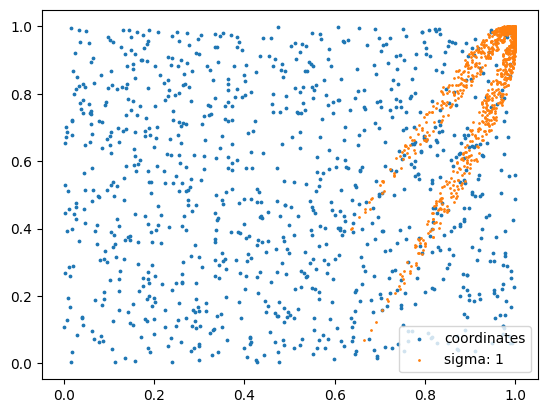

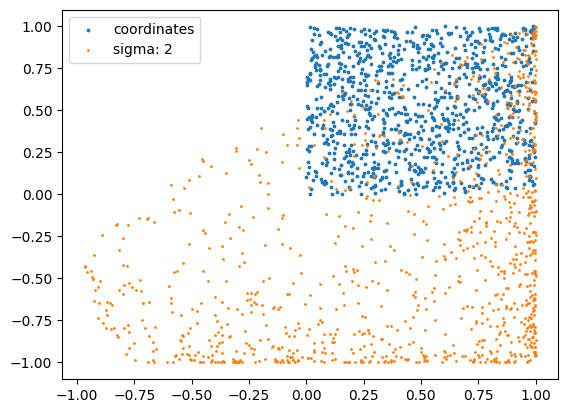

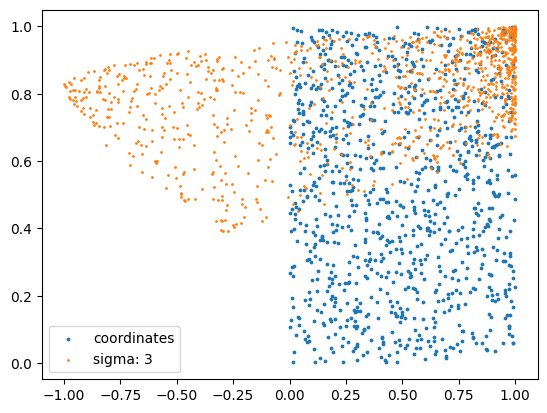

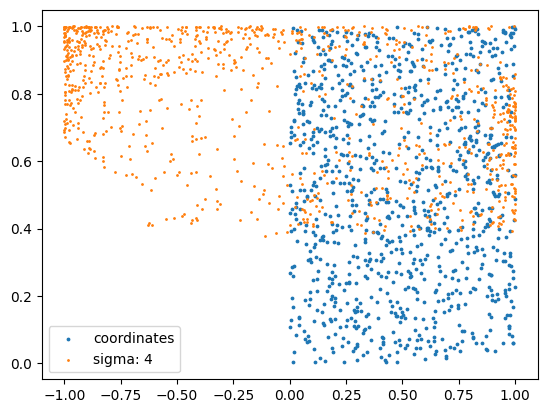

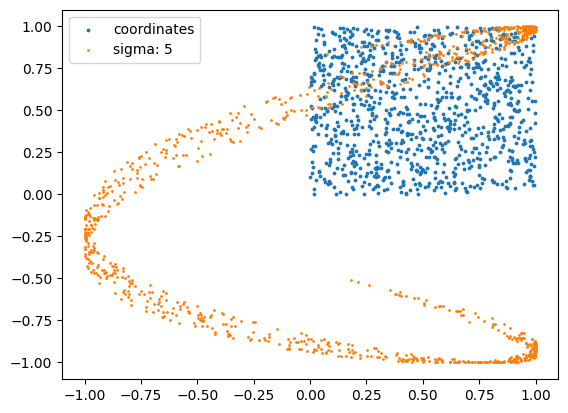

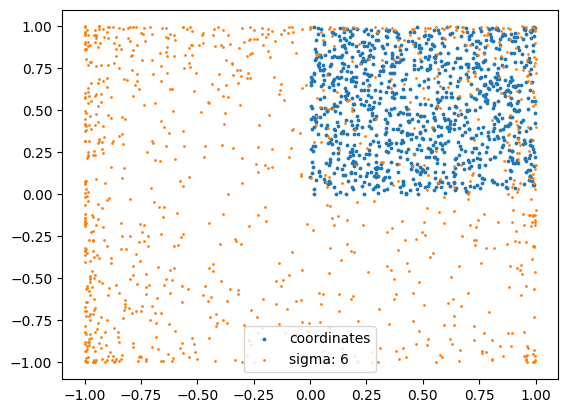

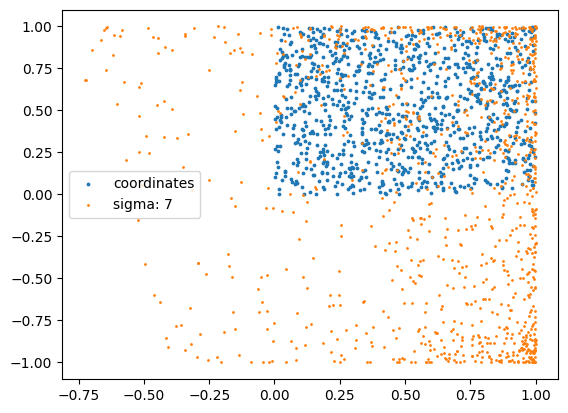

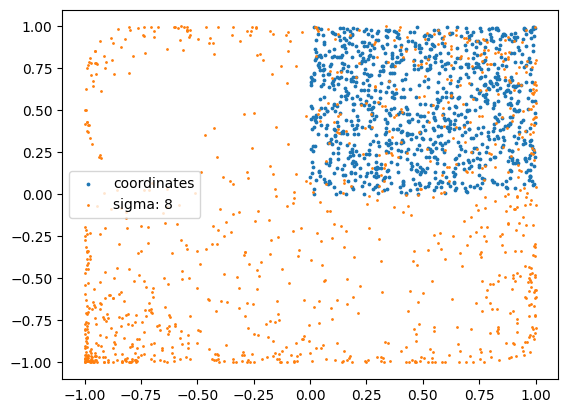

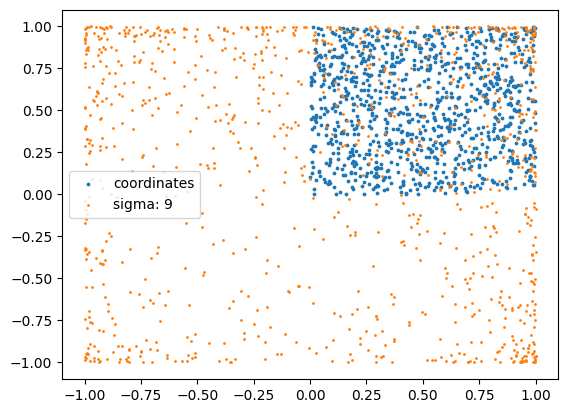

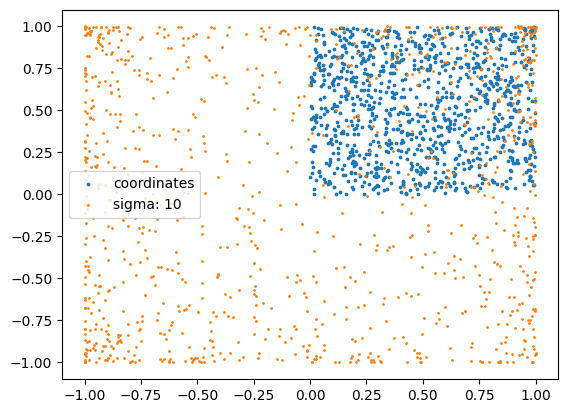

In [95]:
# furier feature embeding...

import torch
import matplotlib.pyplot as plt

def scatter_row_wise(t, name=None, s=3):
    plt.scatter(t[0, :], t[1, :], label=name, s=s)
    plt.legend()

def scatter_col_wise(t, name=None, s=3):
    plt.scatter(t[:, 0], t[:, 1], label=name, s=s)
    plt.legend()

def ffe(x: torch.Tensor, B):    return torch.cat([torch.cos(x @ B), torch.sin(x @ B)], dim=1)

dummy_x = torch.rand([1000, 2])
g = torch.Generator().manual_seed(4)

for sigma in range(1, 11):
    scatter_col_wise(dummy_x, name='coordinates')
    B = torch.randn(size=[2, 128], generator=g) * sigma
    fourier_t = ffe(dummy_x, B)
    scatter_col_wise(fourier_t, name=f'sigma: {sigma}', s=1)
    plt.show()


/var/folders/t4/6xsvx9j91v382r0629q1bjqh0000gn/T/ipykernel_2302/1678846225.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


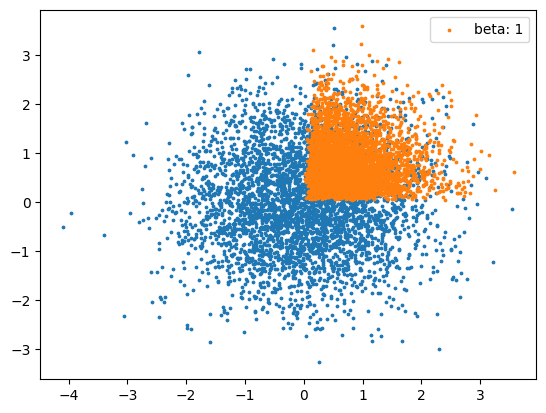

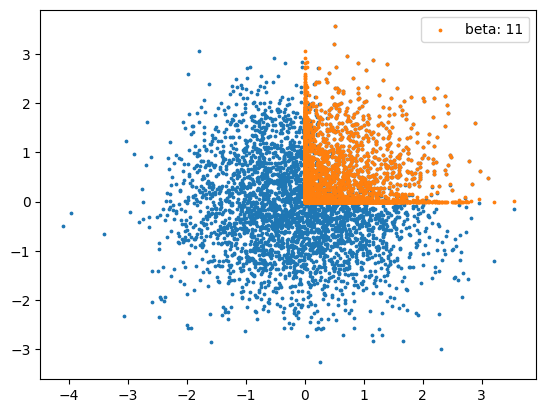

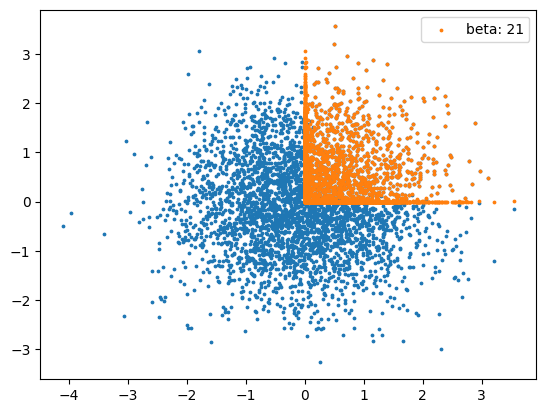

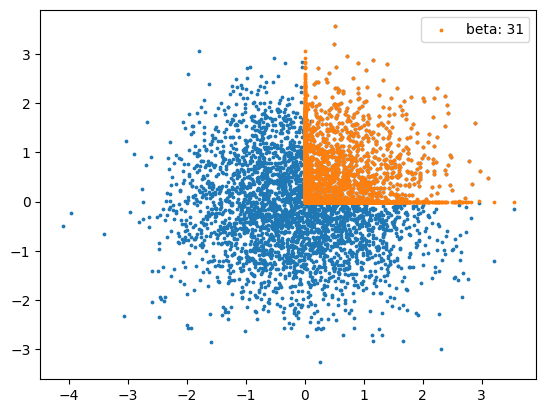

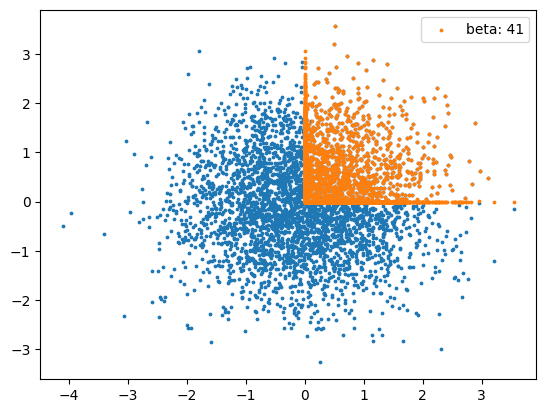

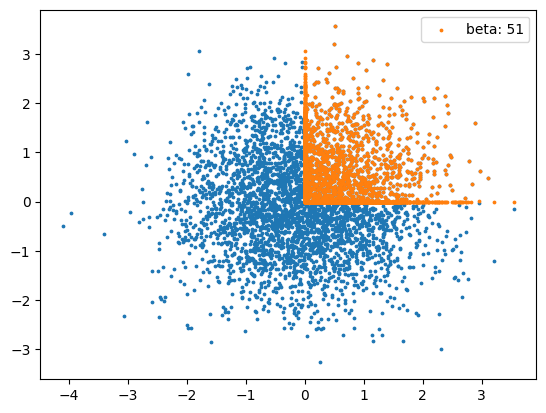

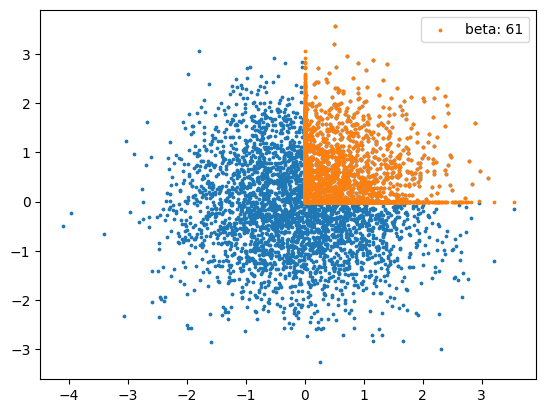

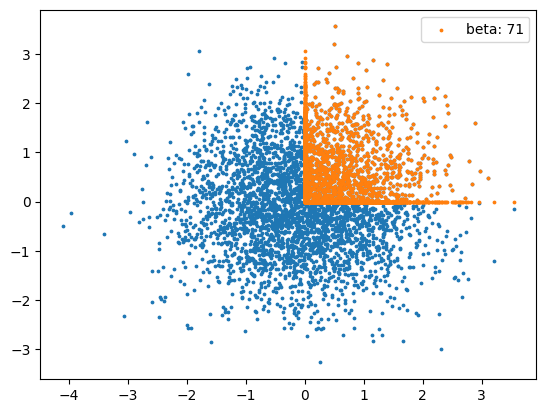

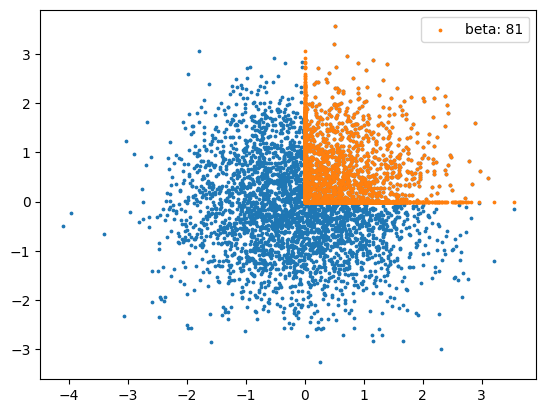

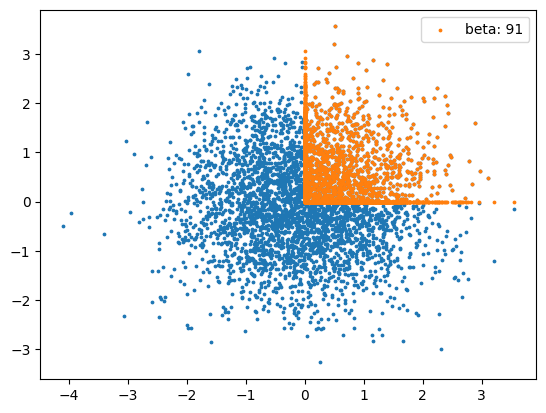

In [113]:
import torch
import torch.nn.functional as F

x = torch.randn([4000, 2])


for b in range(1, 100, 10):
    scatter_col_wise(x)
    out = F.softplus(x, beta=b)
    scatter_col_wise(out, name=f'beta: {b}')
    plt.show()

/var/folders/t4/6xsvx9j91v382r0629q1bjqh0000gn/T/ipykernel_2302/1678846225.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


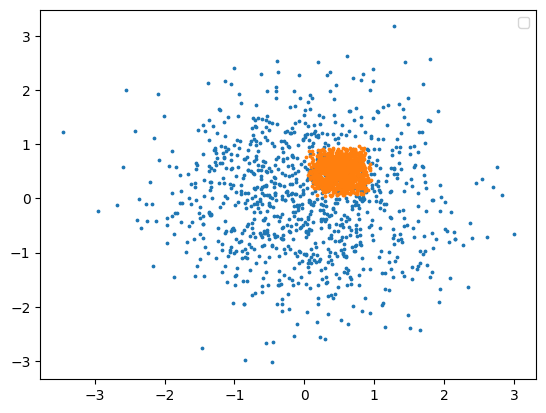

In [116]:
import torch.nn.functional as F

x = torch.randn([1000, 2])
scatter_col_wise(x)

sig_x = F.sigmoid(x)
scatter_col_wise(sig_x)

In [1]:
# RWF testing ...
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

verbose = False

# acceptable inits.
_INITS = {'xavier_normal': nn.init.xavier_normal_, 'xavier_uniform': nn.init.xavier_uniform_}


# spatiotemporal input.
x = torch.rand([100, 2])

# example for lth layer
in_features = 2
out_features = 256 # probably the layers length meaing the num of neuron lets say 16 here
V = torch.empty([out_features, in_features])
if verbose:     print(f'unitialized weight matrix {V}')

init_fn = _INITS.get('', nn.init.xavier_normal_) # a layer of protection in case key is not acceptable.
init_fn(V)
if verbose:     print('after xavier:\n',V)

mu = 1.0;   sigma=0.1
s = mu + sigma * torch.randn(out_features)
# plt.hist(s, bins=30, alpha=0.7)
if verbose:     sns.histplot(s.numpy(), kde=True)
b = torch.zeros(out_features)

# first layer output.
y1 = torch.exp(s) * F.linear(x, V) + b

if verbose:     W = torch.exp(s).unsqueeze(1) * V

In [2]:
from trastuzumab.neural_nets import RWFLinear
import torch

x = torch.rand([1000, 2])
linear1 = RWFLinear(2, 16, initialization='xavier_normal')
linear2 = RWFLinear(16, 16)
linear3 = RWFLinear(16, 16)
linear4 = RWFLinear(16, 3)

linear4(linear3(linear2(linear1(x)))).shape

torch.Size([1000, 3])

In [2]:
from trastuzumab.neural_nets import FCNN

fcnn = FCNN(3, 64, 'xavier_normal', use_rwf=True)
fcnn

neural network weights initialized succesfully - initializer: xavier_normal


FCNN(
  (activation): Tanh()
  (layers): ModuleList(
    (0): RWFLinear(in_features=2, out_features=64, mu=1.0, sigma=0.1)
    (1): RWFLinear(in_features=64, out_features=64, mu=1.0, sigma=0.1)
    (2): RWFLinear(in_features=64, out_features=3, mu=1.0, sigma=0.1)
  )
)

In [72]:
# causal weighting playground ...
import torch

t_bounds = (0.0, 24.0)
N = 20

t_lo, t_hi = t_bounds
t = torch.rand([N, 1]) * t_hi + t_lo

n_chunks = 24

edges = torch.linspace(t_lo, t_hi, n_chunks + 1, device=t.device)
t_flat = t.squeeze(-1)

lo = edges[0]
hi = edges[1]

mask = (t_flat >= lo) & (t_flat < hi)
print(mask)
mask.any()

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False])


tensor(False)

In [27]:
t.any()

tensor(True)

In [79]:
x = torch.randint(1, 5, [3, 2])
print(x)
torch.cumsum(x, dim=0)

tensor([[2, 3],
        [1, 1],
        [2, 2]])


tensor([[2, 3],
        [3, 4],
        [5, 6]])

In [92]:
tensor = torch.randn([1, 2, 1, 4])
tensor.squeeze(0).shape

torch.zeros(())

tensor(0.)

In [2]:
from trastuzumab.causal import causal_weighted_residual
import torch

n_points = 2000
residual_terms = {'pde0': torch.rand([n_points, 1]), 'pde1': torch.rand([n_points, 1]), 'pde2': torch.rand([n_points, 1])}
w = {'pde0': torch.tensor(1.0), 'pde1': torch.tensor(1.0), 'pde2': torch.tensor(1.0)}
weights={'pde0': w['pde0'], 'pde1': w['pde1'], 'pde2': w['pde2']}
t = torch.linspace(0, 1.0, n_points)

causal_weighted_residual(residual_terms, weights, t, (0.0, 1.0), 24, 1.0)

per-chunk-loss [chunk: 0] - [0.0 - 0.0416666679084301] [tensor(1.0603)]
per-chunk-loss [chunk: 1] - [0.0416666679084301 - 0.0833333358168602] [tensor(1.0603), tensor(1.0620)]
per-chunk-loss [chunk: 2] - [0.0833333358168602 - 0.125] [tensor(1.0603), tensor(1.0620), tensor(1.0347)]
per-chunk-loss [chunk: 3] - [0.125 - 0.1666666716337204] [tensor(1.0603), tensor(1.0620), tensor(1.0347), tensor(0.9999)]
per-chunk-loss [chunk: 4] - [0.1666666716337204 - 0.2083333432674408] [tensor(1.0603), tensor(1.0620), tensor(1.0347), tensor(0.9999), tensor(1.0071)]
per-chunk-loss [chunk: 5] - [0.2083333432674408 - 0.25] [tensor(1.0603), tensor(1.0620), tensor(1.0347), tensor(0.9999), tensor(1.0071), tensor(1.0316)]
per-chunk-loss [chunk: 6] - [0.25 - 0.2916666865348816] [tensor(1.0603), tensor(1.0620), tensor(1.0347), tensor(0.9999), tensor(1.0071), tensor(1.0316), tensor(1.0679)]
per-chunk-loss [chunk: 7] - [0.2916666865348816 - 0.3333333432674408] [tensor(1.0603), tensor(1.0620), tensor(1.0347), tenso

(tensor(0.0675),
 tensor([1.0603, 1.0620, 1.0347, 0.9999, 1.0071, 1.0316, 1.0679, 1.0027, 0.9855,
         1.0676, 0.9770, 0.9774, 1.0463, 0.9557, 1.0216, 0.9827, 0.9694, 1.0483,
         1.0389, 1.0173, 1.0458, 1.0160, 0.8720, 1.0640]),
 tensor([1.0000e+00, 3.4634e-01, 1.1975e-01, 4.2549e-02, 1.5654e-02, 5.7181e-03,
         2.0382e-03, 7.0059e-04, 2.5702e-04, 9.5934e-05, 3.2984e-05, 1.2417e-05,
         4.6722e-06, 1.6411e-06, 6.3107e-07, 2.2720e-07, 8.5042e-08, 3.2257e-08,
         1.1307e-08, 4.0011e-09, 1.4466e-09, 5.0838e-10, 1.8406e-10, 7.6962e-11]))

In [8]:
d = {'pde0': torch.tensor([1]), 'pde2': torch.tensor([2])}

sum(d.values())

tensor([3])

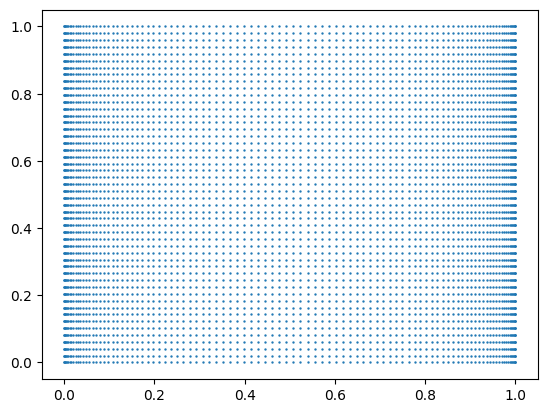

In [29]:
# chebyshev nodes ...

import numpy as np
import matplotlib.pyplot as plt

def scatter(p):
    plt.scatter(p[:, 0:1], p[:, 1], s=0.5)

x_min = 0.0;    x_max = 1.0;    nx = 100;    theta_x = np.linspace(np.pi, 0, nx)
y_min = 0.0;    y_max = 1.0;    ny = 50;    theta_y = np.linspace(np.pi, 0, ny)

x = 0.5 * (x_max + x_min) - 0.5 * (x_max - x_min) * np.cos(theta_x)
# y = 0.5 * (y_max + y_min) - 0.5 * (y_max - y_min) * np.cos(theta_y)
y = np.linspace(0, 1, ny)

X, Y = np.meshgrid(x, y)
p = np.column_stack((X.ravel(), Y.ravel()))

scatter(p)


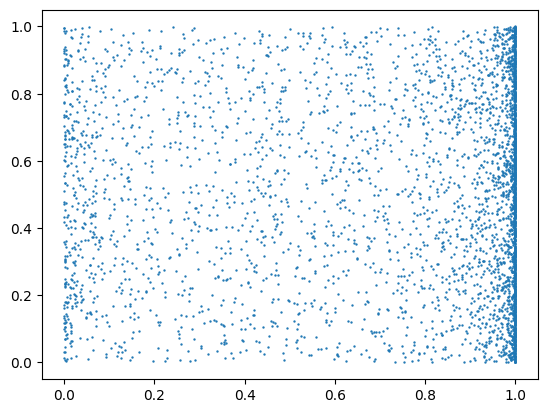

In [57]:
# beta distribution ...

import torch
from torch.distributions import Beta
n_points = 4000
b = Beta(torch.tensor([0.5]), torch.tensor([0.2]))
x = b.sample([n_points, 1]).squeeze(-1)

y = b.sample([n_points, 1]).squeeze(-1)
y = torch.linspace(0, 1, n_points).reshape(-1, 1)

p = torch.cat((x, y), dim=1)
scatter(p)

In [74]:
mask = torch.isclose(p[:, 0:1], torch.ones_like(p[:, 0:1]), rtol=1e-7)
p[:, 0:1][mask]

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [16]:
# moving average ...

import pandas as pd

data = [10, 20, 30, 40, 50, 60]
df = pd.DataFrame(data, columns=['Values'])
df['MA'] = df['Values'].rolling(window=3).mean()
df['CA'] = df['Values'].expanding().mean()
list(df['MA'])

[nan, nan, 20.0, 30.0, 40.0, 50.0]

In [ ]:
# matrix trace

import numpy as np

B = np.random.randint(0,10, [5, 5])
if not np.trace(B) == np.diag(B).sum():     raise ValueError
print(B)

def TRACE(matrix):
    return sum(matrix[i][i] for i in range(len(matrix)))

TRACE(B)

[[6 7 5 4 4]
 [8 0 7 8 1]
 [7 8 2 2 6]
 [7 5 5 3 7]
 [5 9 7 6 3]]


In [5]:
# grad-norm loss balancing weighting ...

from dataclasses import dataclass, asdict

@dataclass(frozen=True)
class GroupLambdas:
    ic: float
    bc: float
    r: float

    def as_dict(self):
        return asdict(self)

l = GroupLambdas(ic=1.0, bc=1.0, r=1.0)
l.as_dict()


{'ic': 1.0, 'bc': 1.0, 'r': 1.0}

In [7]:
import torch
from trastuzumab.weighting import _grad_norm, gradient_norm_lambdas, GroupLambdas


net = torch.nn.Sequential(torch.nn.Linear(2, 16), torch.nn.Tanh(), torch.nn.Linear(16, 1))
print(net)

params = list(net.parameters())
x = torch.rand(20, 2)

out = net(x)
L_ic = 0.001 * out.pow(2).mean()
L_bc = out.pow(2).mean()
L_r = 1000 * out.pow(2).mean()

group_losses = {'ic': L_ic, 'bc': L_bc, 'r': L_r}
print(f'initial losses: {group_losses}')


raw_norms = {name: _grad_norm(loss, params) for name, loss in group_losses.items()}
print('raw norms: ',raw_norms)

lambdas = gradient_norm_lambdas(group_losses, list(net.parameters()))
print(f'lambda_hat: {lambdas}')

weighted_norms = {}
for name, loss in group_losses.items():
    weighted_loss = lambdas.as_dict()[name] * loss
    weighted_norms[name] = _grad_norm(weighted_loss, list(net.parameters()))

weighted_norms

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): Tanh()
  (2): Linear(in_features=16, out_features=1, bias=True)
)
initial losses: {'ic': tensor(2.6768e-06, grad_fn=<MulBackward0>), 'bc': tensor(0.0027, grad_fn=<MeanBackward0>), 'r': tensor(2.6768, grad_fn=<MulBackward0>)}
raw norms:  {'ic': 0.0002307611721334979, 'bc': 0.23076118528842926, 'r': 230.7611541748047}
lambda_hat: GroupLambdas(ic=1001000.9222332851, bc=1001.0008651695358, r=1.0010010001349083)


{'ic': 230.99215698242188, 'bc': 230.9921112060547, 'r': 230.99215698242188}